# 🌿 Paris garantit-elle une équité d'accès aux îlots de fraîcheur selon les arrondissements ?

## ❓ Hypothèse de travail
- **H0** : La distribution des îlots de fraîcheur est proportionnelle à la population de chaque arrondissement (équité)
- **H1** : Il existe une inégalité significative — certains arrondissements sont structurellement sous-équipés

## 🧠 Méthodologie 
1. Collecte via API Open Data Paris
2. Croisement avec données population INSEE 2021
3. Nettoyage et validation des données
4. Analyse exploratoire + calcul du ratio équipements/habitant
5. Test statistique (corrélation de Spearman + Chi²)
6. Clustering géographique (KMeans avec méthode du coude)
7. Visualisations : carte choroplèthe, heatmap, crosstab
8. Conclusion chiffrée + recommandations

## ⚠️ Limites de l'étude
- Le dataset peut être incomplet (équipements non référencés par la ville)
- Population issue du recensement INSEE 2021 (chiffres stables mais pas temps réel)
- L'analyse ne pondère pas la capacité ou la surface des équipements
- Le clustering géographique ne tient pas compte des frontières administratives

---
## 📦 CELLULE 1 — Installation des dépendances

In [1]:
# ============================================================
# CELLULE 1 — Installation des dépendances (si nécessaire)
# ============================================================
# Décommentez les lignes ci-dessous si les librairies ne sont pas installées
# !pip install folium scikit-learn scipy seaborn requests
print('Dépendances prêtes.')

Dépendances prêtes.


---
## 📚 CELLULE 2 — Import de toutes les librairies

In [5]:
!pip install folium

  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)


In [6]:
# ============================================================
# CELLULE 2 — Import de toutes les librairies
# ============================================================
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

from sklearn.cluster import KMeans
from scipy.stats import spearmanr, chi2_contingency

import folium
from folium.plugins import HeatMap

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Toutes les librairies importées avec succès.')

✅ Toutes les librairies importées avec succès.


---
## 🌐 CELLULE 3 — Collecte des données via API Open Data Paris

In [7]:
# ============================================================
# CELLULE 3 — Collecte des données via API Open Data Paris
# Pagination automatique pour récupérer TOUS les enregistrements
# ============================================================
all_data = []
limit = 100
offset = 0

print('🔄 Collecte en cours...')

while True:
    url = (
        f'https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/'
        f'ilots-de-fraicheur-equipements-activites/records'
        f'?limit={limit}&offset={offset}&select=*'
    )
    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        data = response.json()
    except requests.exceptions.Timeout:
        print(f'⚠️  Timeout à offset={offset}, tentative ignorée.')
        offset += limit
        continue
    except requests.exceptions.HTTPError as e:
        print(f'❌ Erreur HTTP : {e}')
        break
    except Exception as e:
        print(f'❌ Erreur inattendue : {e}')
        break

    if 'results' not in data or len(data['results']) == 0:
        break

    all_data.extend(data['results'])
    offset += limit

df_raw = pd.json_normalize(all_data)

print(f'✅ Collecte terminée.')
print(f'   → {len(df_raw)} enregistrements récupérés')
print(f'   → {df_raw.shape[1]} colonnes disponibles')
df_raw.head()

🔄 Collecte en cours...
✅ Collecte terminée.
   → 548 enregistrements récupérés
   → 22 colonnes disponibles


,identifiant,id_dicom,nom,type,payant,adresse,arrondissement,statut_ouverture,horaires_periode,horaires_lundi,...,horaires_jeudi,horaires_vendredi,horaires_samedi,horaires_dimanche,proposition_usager,geo_shape.type,geo_shape.geometry.coordinates,geo_shape.geometry.type,geo_point_2d.lon,geo_point_2d.lat
0,LC35,19465,Eglise Saint-François de Sales,Lieux de culte,Non,15 RUE AMPERE,75017,None,"Les horaires étant susceptibles d'évoluer, mer...",None,...,None,None,None,None,Non,Feature,"[2.305013903156183, 48.884914071189634]",Point,2.305014,48.884914
1,OM50,None,KIOSQUE A MUSIQUE SQUARE JEAN CHERIOUX,Ombrière pérenne,Non,260 RUE DE VAUGIRARD,75015,None,Horaires d'ouverture de l'espace vert,None,...,None,None,None,None,Non,Feature,"[2.3005876556468787, 48.84024431176974]",Point,2.300588,48.840244
2,LC96,19484,Eglise Saint-Julien Le Pauvre,Lieux de culte,Non,1 RUE SAINT-JULIEN LE PAUVRE,75005,None,"Les horaires étant susceptibles d'évoluer, mer...",None,...,None,None,None,None,Non,Feature,"[2.3470575838867553, 48.8520087350826]",Point,2.347058,48.852009
3,LC100,None,Cathedrale Saint-Vladimir Le Grand,Lieux de culte,Non,51 RUE SAINTS-PERES,75006,None,"Les horaires étant susceptibles d'évoluer, mer...",None,...,None,None,None,None,Non,Feature,"[2.330968395289091, 48.85471003474433]",Point,2.330968,48.854710
4,MU74,None,Maison du Japon,Musée,Oui,101Bis Quai Branly,75015,None,None,None,...,None,None,None,None,Non,Feature,"[2.289772488194873, 48.85472933886124]",Point,2.289772,48.854729


---
## 🔍 CELLULE 4 — Exploration initiale des données

In [9]:
# ============================================================
# CELLULE 4 — Exploration initiale des données (CORRIGÉE)
# ============================================================
print('=== DIMENSIONS ===')
print(f'Lignes : {df_raw.shape[0]} | Colonnes : {df_raw.shape[1]}\n')

print('=== COLONNES DISPONIBLES ===')
for col in df_raw.columns:
    print(f'  - {col}')

print('\n=== VALEURS MANQUANTES ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
print(missing_df[missing_df['Manquants'] > 0].sort_values('Pourcentage (%)', ascending=False).to_string())

print(f'\n=== DOUBLONS ===')
# ✅ FIX : exclure les colonnes contenant des types non-hashables (listes, dicts)
cols_hashables = [
    col for col in df_raw.columns
    if not df_raw[col].apply(lambda x: isinstance(x, (list, dict))).any()
]
nb_doublons = df_raw[cols_hashables].duplicated().sum()
print(f'Doublons détectés : {nb_doublons}')
print(f'  (colonnes exclues car non-hashables : {[c for c in df_raw.columns if c not in cols_hashables]})')

print(f'\n=== APERÇU DES TYPES D\'ÉQUIPEMENTS ===')
if 'type' in df_raw.columns:
    print(df_raw['type'].value_counts().to_string())

=== DIMENSIONS ===
Lignes : 548 | Colonnes : 22

=== COLONNES DISPONIBLES ===
  - identifiant
  - id_dicom
  - nom
  - type
  - payant
  - adresse
  - arrondissement
  - statut_ouverture
  - horaires_periode
  - horaires_lundi
  - horaires_mardi
  - horaires_mercredi
  - horaires_jeudi
  - horaires_vendredi
  - horaires_samedi
  - horaires_dimanche
  - proposition_usager
  - geo_shape.type
  - geo_shape.geometry.coordinates
  - geo_shape.geometry.type
  - geo_point_2d.lon
  - geo_point_2d.lat

=== VALEURS MANQUANTES ===
                    Manquants  Pourcentage (%)
statut_ouverture          517             94.3
horaires_lundi            425             77.6
horaires_mardi            425             77.6
horaires_mercredi         425             77.6
horaires_jeudi            425             77.6
horaires_vendredi         425             77.6
horaires_dimanche         425             77.6
horaires_samedi           424             77.4
id_dicom                  303             55.3
hora

---
## 🧹 CELLULE 5 — Nettoyage et préparation des données

In [11]:
# ============================================================
# CELLULE 5 — Nettoyage et préparation des données
# On garde les colonnes utiles ET on justifie chaque choix
# ============================================================

df = df_raw.copy()

# Colonnes retenues :
#   nom            → identifiant lisible de l'équipement
#   type           → catégorie (fontaine, parc, piscine...)
#   arrondissement → unité géographique d'analyse principale
#   geo_point_2d.lat / .lon → coordonnées pour les cartes et le clustering
cols_utiles = ['nom', 'type', 'arrondissement', 'geo_point_2d.lat', 'geo_point_2d.lon']

# Vérifier que les colonnes existent bien
cols_utiles = [c for c in cols_utiles if c in df.columns]
df = df[cols_utiles]

# Suppression des lignes avec valeurs manquantes ESSENTIELLES
avant = len(df)
df = df.dropna()
print(f'Lignes supprimées pour valeurs manquantes : {avant - len(df)} ({((avant - len(df))/avant*100):.1f}%)')

# Suppression des doublons
avant2 = len(df)
df = df.drop_duplicates()
print(f'Doublons supprimés : {avant2 - len(df)}')

# Validation des coordonnées géographiques (Paris = lat 48.8-48.95, lon 2.25-2.42)
avant3 = len(df)
df = df[
    df['geo_point_2d.lat'].between(48.75, 48.95) &
    df['geo_point_2d.lon'].between(2.20, 2.47)
]
print(f'Lignes hors zone Paris supprimées : {avant3 - len(df)}')

# Nettoyage du nom d'arrondissement (harmonisation des formats)
df['arrondissement'] = df['arrondissement'].astype(str).str.strip()

print(f'\n✅ Dataset nettoyé : {len(df)} équipements valides')
print(f'   → Arrondissements distincts : {df["arrondissement"].nunique()}')
print(f'   → Types d\'équipements distincts : {df["type"].nunique()}')
df.head()

Lignes supprimées pour valeurs manquantes : 1 (0.2%)
Doublons supprimés : 0
Lignes hors zone Paris supprimées : 0

✅ Dataset nettoyé : 547 équipements valides
   → Arrondissements distincts : 20
   → Types d'équipements distincts : 12


,nom,type,arrondissement,geo_point_2d.lat,geo_point_2d.lon
0,Eglise Saint-François de Sales,Lieux de culte,75017,48.884914,2.305014
1,KIOSQUE A MUSIQUE SQUARE JEAN CHERIOUX,Ombrière pérenne,75015,48.840244,2.300588
2,Eglise Saint-Julien Le Pauvre,Lieux de culte,75005,48.852009,2.347058
3,Cathedrale Saint-Vladimir Le Grand,Lieux de culte,75006,48.854710,2.330968
4,Maison du Japon,Musée,75015,48.854729,2.289772


---
## 👥 CELLULE 6 — Données de population INSEE 2021

In [12]:
# ============================================================
# CELLULE 6 — Données de population par arrondissement
# Source : INSEE — Recensement de la population 2021
# URL : https://www.insee.fr/fr/statistiques/2011101
# ============================================================

population_insee = {
    'Paris 1er Arrondissement':   16266,
    'Paris 2ème Arrondissement':  21116,
    'Paris 3ème Arrondissement':  34115,
    'Paris 4ème Arrondissement':  27769,
    'Paris 5ème Arrondissement':  58850,
    'Paris 6ème Arrondissement':  41110,
    'Paris 7ème Arrondissement':  51535,
    'Paris 8ème Arrondissement':  36808,
    'Paris 9ème Arrondissement':  59555,
    'Paris 10ème Arrondissement': 93373,
    'Paris 11ème Arrondissement': 147193,
    'Paris 12ème Arrondissement': 141162,
    'Paris 13ème Arrondissement': 181557,
    'Paris 14ème Arrondissement': 136574,
    'Paris 15ème Arrondissement': 233392,
    'Paris 16ème Arrondissement': 165446,
    'Paris 17ème Arrondissement': 167826,
    'Paris 18ème Arrondissement': 196033,
    'Paris 19ème Arrondissement': 183455,
    'Paris 20ème Arrondissement': 195218,
}

df_pop = pd.DataFrame(list(population_insee.items()), columns=['arrondissement_ref', 'population'])

print('Population chargée pour les 20 arrondissements.')
print(f'Population totale Paris : {df_pop["population"].sum():,} habitants')
df_pop

Population chargée pour les 20 arrondissements.
Population totale Paris : 2,188,353 habitants


,arrondissement_ref,population
0,Paris 1er Arrondissement,16266
1,Paris 2ème Arrondissement,21116
2,Paris 3ème Arrondissement,34115
3,Paris 4ème Arrondissement,27769
4,Paris 5ème Arrondissement,58850
5,Paris 6ème Arrondissement,41110
6,Paris 7ème Arrondissement,51535
7,Paris 8ème Arrondissement,36808
8,Paris 9ème Arrondissement,59555
9,Paris 10ème Arrondissement,93373


---
## 🔗 CELLULE 7 — Fusion îlots + population

In [17]:
# ============================================================
# CELLULE 7 — Fusion îlots + population (VERSION ROBUSTE)
# Normalisation automatique des noms d'arrondissements
# ============================================================

# Compter les îlots par arrondissement
df_arr = df['arrondissement'].value_counts().reset_index()
df_arr.columns = ['arrondissement', 'nb_ilots']

print("Valeurs brutes dans le dataset :")
print(df_arr['arrondissement'].tolist())

# ── Fonction de normalisation ──────────────────────────────
import re

def normaliser_arrondissement(s):
    """
    Convertit n'importe quel format vers 'Paris Xème Arrondissement'
    Gère : '75001', 'Paris 1er', 'Paris 02', 'Paris (75001)', etc.
    """
    s = str(s).strip()

    # Cas : code postal ou code INSEE (75001 → 75020)
    m = re.search(r'750(\d{2})', s)
    if m:
        num = int(m.group(1))
    else:
        # Cas : extraction du numéro depuis le texte
        m = re.search(r'\b(\d{1,2})\b', s)
        if m:
            num = int(m.group(1))
        else:
            return s  # Impossible à normaliser → on laisse tel quel

    if num == 1:
        return 'Paris 1er Arrondissement'
    else:
        return f'Paris {num}ème Arrondissement'

# ── Application ───────────────────────────────────────────
df_arr['arrondissement_ref'] = df_arr['arrondissement'].apply(normaliser_arrondissement)

print("\nAprès normalisation :")
for orig, norm in zip(df_arr['arrondissement'], df_arr['arrondissement_ref']):
    print(f"  '{orig}' → '{norm}'")

# ── Fusion ─────────────────────────────────────────────────
df_merge = df_arr.merge(df_pop, on='arrondissement_ref', how='inner')

# ── Diagnostic si la fusion échoue encore ─────────────────
if len(df_merge) == 0:
    print("\n❌ Fusion toujours vide. Clés normalisées non trouvées dans df_pop.")
    print("Clés normalisées :", sorted(df_arr['arrondissement_ref'].tolist()))
    print("Clés population  :", sorted(df_pop['arrondissement_ref'].tolist()))
else:
    # Calcul du ratio
    df_merge['ratio_pour_10000'] = (
        df_merge['nb_ilots'] / df_merge['population'] * 10000
    ).round(2)
    df_merge = df_merge.sort_values('ratio_pour_10000', ascending=False).reset_index(drop=True)

    print(f"\n✅ Fusion réussie : {len(df_merge)} arrondissements")
    print(f"Ratio moyen Paris : {df_merge['ratio_pour_10000'].mean():.2f} îlots / 10 000 hab.")
    print()
    print(df_merge[['arrondissement', 'nb_ilots', 'population', 'ratio_pour_10000']].to_string(index=False))

Valeurs brutes dans le dataset :
['75020', '75012', '75019', '75018', '75015', '75016', '75014', '75013', '75007', '75017', '75008', '75001', '75011', '75004', '75005', '75010', '75003', '75009', '75006', '75002']

Après normalisation :
  '75020' → 'Paris 20ème Arrondissement'
  '75012' → 'Paris 12ème Arrondissement'
  '75019' → 'Paris 19ème Arrondissement'
  '75018' → 'Paris 18ème Arrondissement'
  '75015' → 'Paris 15ème Arrondissement'
  '75016' → 'Paris 16ème Arrondissement'
  '75014' → 'Paris 14ème Arrondissement'
  '75013' → 'Paris 13ème Arrondissement'
  '75007' → 'Paris 7ème Arrondissement'
  '75017' → 'Paris 17ème Arrondissement'
  '75008' → 'Paris 8ème Arrondissement'
  '75001' → 'Paris 1er Arrondissement'
  '75011' → 'Paris 11ème Arrondissement'
  '75004' → 'Paris 4ème Arrondissement'
  '75005' → 'Paris 5ème Arrondissement'
  '75010' → 'Paris 10ème Arrondissement'
  '75003' → 'Paris 3ème Arrondissement'
  '75009' → 'Paris 9ème Arrondissement'
  '75006' → 'Paris 6ème Arrondiss

In [18]:
# ============================================================
# DIAGNOSTIC — Vérifier pourquoi df_merge est vide
# ============================================================
print("=== NOMS dans le dataset îlots ===")
print(sorted(df['arrondissement'].unique().tolist()))

print("\n=== NOMS dans la table population ===")
print(sorted(df_pop['arrondissement_ref'].tolist()))

print(f"\n=== Taille de df_merge : {len(df_merge)} lignes ===")

=== NOMS dans le dataset îlots ===
['75001', '75002', '75003', '75004', '75005', '75006', '75007', '75008', '75009', '75010', '75011', '75012', '75013', '75014', '75015', '75016', '75017', '75018', '75019', '75020']

=== NOMS dans la table population ===
['Paris 10ème Arrondissement', 'Paris 11ème Arrondissement', 'Paris 12ème Arrondissement', 'Paris 13ème Arrondissement', 'Paris 14ème Arrondissement', 'Paris 15ème Arrondissement', 'Paris 16ème Arrondissement', 'Paris 17ème Arrondissement', 'Paris 18ème Arrondissement', 'Paris 19ème Arrondissement', 'Paris 1er Arrondissement', 'Paris 20ème Arrondissement', 'Paris 2ème Arrondissement', 'Paris 3ème Arrondissement', 'Paris 4ème Arrondissement', 'Paris 5ème Arrondissement', 'Paris 6ème Arrondissement', 'Paris 7ème Arrondissement', 'Paris 8ème Arrondissement', 'Paris 9ème Arrondissement']

=== Taille de df_merge : 20 lignes ===


---
## 📊 CELLULE 8 — Visualisation principale : ratio îlots / habitant

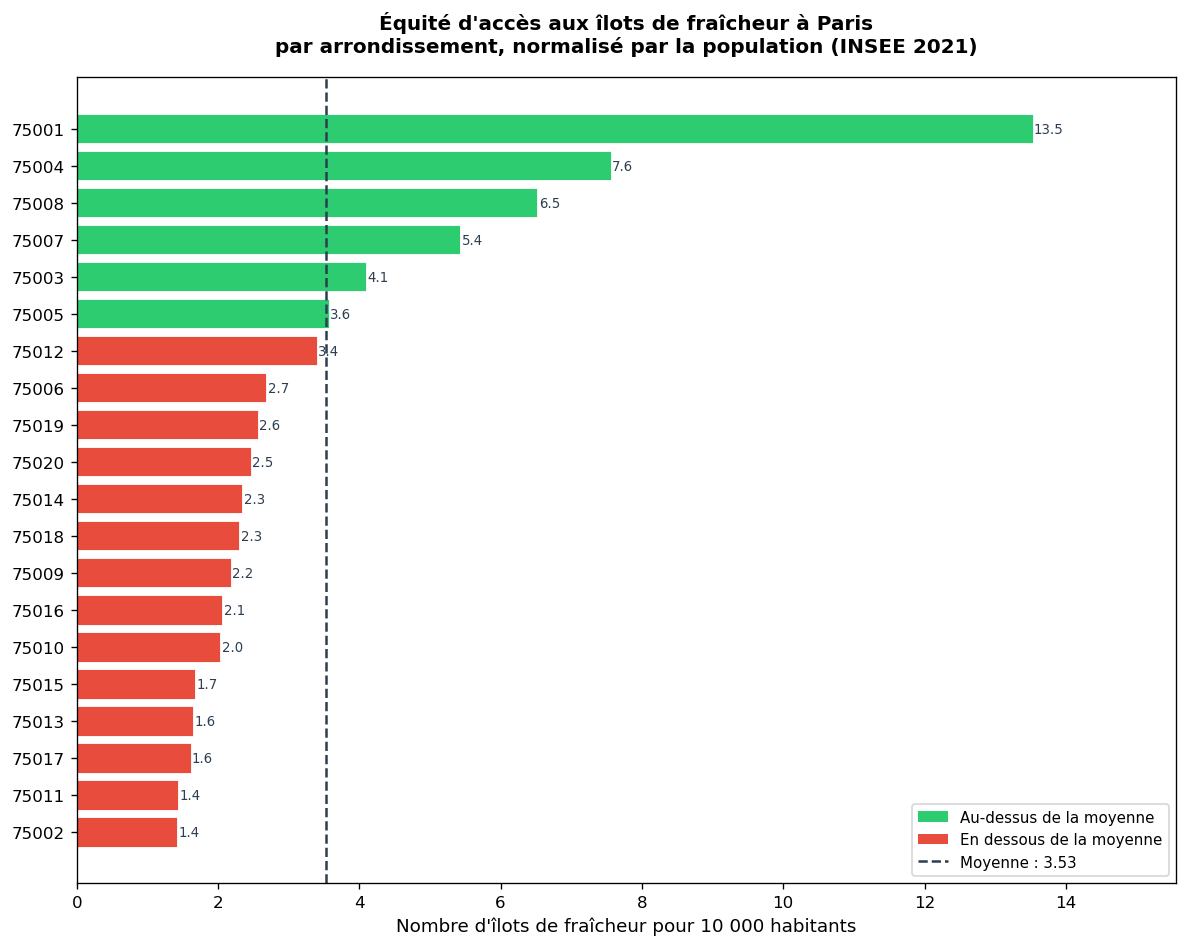

📊 Graphique sauvegardé : ratio_ilots_par_arrondissement.png


In [19]:
# ============================================================
# CELLULE 8 — Visualisation principale : ratio îlots / habitant
# C'est LE graphique clé qui répond à notre hypothèse
# ============================================================

from matplotlib.patches import Patch

moyenne = df_merge['ratio_pour_10000'].mean()
df_sorted = df_merge.sort_values('ratio_pour_10000')
couleurs = ['#e74c3c' if v < moyenne else '#2ecc71' for v in df_sorted['ratio_pour_10000']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(df_sorted['arrondissement'], df_sorted['ratio_pour_10000'],
               color=couleurs, edgecolor='white', linewidth=0.5)

ax.axvline(moyenne, color='#2c3e50', linestyle='--', linewidth=1.5)

for bar, val in zip(bars, df_sorted['ratio_pour_10000']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', ha='left', fontsize=8, color='#2c3e50')

ax.set_xlabel("Nombre d'îlots de fraîcheur pour 10 000 habitants", fontsize=11)
ax.set_title("Équité d'accès aux îlots de fraîcheur à Paris\npar arrondissement, normalisé par la population (INSEE 2021)",
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlim(0, df_sorted['ratio_pour_10000'].max() * 1.15)

legend_elements = [
    Patch(facecolor='#2ecc71', label='Au-dessus de la moyenne'),
    Patch(facecolor='#e74c3c', label='En dessous de la moyenne'),
    plt.Line2D([0], [0], color='#2c3e50', linestyle='--', label=f'Moyenne : {moyenne:.2f}')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('ratio_ilots_par_arrondissement.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Graphique sauvegardé : ratio_ilots_par_arrondissement.png')

## 📌 Interprétation — Graphique du ratio

Ce graphique est central : il répond directement à notre hypothèse en comparant le nombre d'îlots
de fraîcheur **rapporté à la population** de chaque arrondissement.

- **En vert** : arrondissements mieux dotés que la moyenne parisienne
- **En rouge** : arrondissements sous-dotés par rapport à leur population

Si la distribution était parfaitement équitable, toutes les barres seraient identiques.
Les écarts visibles indiquent une **inégalité de distribution** — qu'il faudra valider statistiquement.

---
## 📐 CELLULE 9 — Test statistique de Spearman

In [20]:
# ============================================================
# CELLULE 9 — Test statistique de Spearman
# Question : y a-t-il une corrélation entre population et nb d'îlots ?
# Si OUI et forte → distribution équitable
# Si NON ou faible → inégalité structurelle
# ============================================================

corr, pvalue = spearmanr(df_merge['population'], df_merge['nb_ilots'])

print('=' * 55)
print('TEST DE CORRÉLATION DE SPEARMAN')
print("Population vs Nombre d'îlots de fraîcheur")
print('=' * 55)
print(f'Coefficient de corrélation (ρ) : {corr:.3f}')
print(f'P-value                        : {pvalue:.4f}')
print()

if pvalue < 0.05:
    print('✅ Résultat SIGNIFICATIF (p < 0.05)')
    if corr > 0.7:
        print("   → Forte corrélation positive : distribution RELATIVEMENT équitable")
        print("   → H0 partiellement confirmée : plus un arrondissement est peuplé, plus il a d'îlots")
    elif corr > 0.4:
        print("   → Corrélation modérée : équité imparfaite, des inégalités existent")
        print('   → H1 partiellement confirmée')
    else:
        print("   → Faible corrélation : distribution NON proportionnelle à la population")
        print('   → H1 confirmée : inégalité structurelle détectée')
else:
    print('❌ Résultat NON significatif (p >= 0.05)')
    print("   → Pas de corrélation démontrée entre population et nb d'îlots")
    print('   → H1 confirmée : la distribution ne suit pas la logique démographique')

print()
print('Interprétation du coefficient ρ :')
print('  ρ proche de  1 → forte corrélation positive')
print('  ρ proche de  0 → pas de corrélation')
print("  ρ proche de -1 → corrélation négative (plus peuplé = moins d'îlots)")

TEST DE CORRÉLATION DE SPEARMAN
Population vs Nombre d'îlots de fraîcheur
Coefficient de corrélation (ρ) : 0.729
P-value                        : 0.0003

✅ Résultat SIGNIFICATIF (p < 0.05)
   → Forte corrélation positive : distribution RELATIVEMENT équitable
   → H0 partiellement confirmée : plus un arrondissement est peuplé, plus il a d'îlots

Interprétation du coefficient ρ :
  ρ proche de  1 → forte corrélation positive
  ρ proche de  0 → pas de corrélation
  ρ proche de -1 → corrélation négative (plus peuplé = moins d'îlots)


---
## 📐 CELLULE 10 — Test du Chi² (équité de distribution)

In [21]:
# ============================================================
# CELLULE 10 — Test du Chi² (équité de distribution)
# Compare la distribution OBSERVÉE à la distribution ATTENDUE
# si elle était parfaitement proportionnelle à la population
# ============================================================

from scipy.stats import chisquare

total_ilots = df_merge['nb_ilots'].sum()
total_pop   = df_merge['population'].sum()

# Distribution attendue = proportionnelle à la population
df_merge['nb_ilots_attendu'] = (df_merge['population'] / total_pop * total_ilots).round(1)

chi2_stat, p_chi2 = chisquare(f_obs=df_merge['nb_ilots'], f_exp=df_merge['nb_ilots_attendu'])

print('=' * 55)
print('TEST DU CHI² — Équité de distribution')
print('H0 : distribution proportionnelle à la population')
print('=' * 55)
print(f'Statistique Chi²  : {chi2_stat:.2f}')
print(f'P-value           : {p_chi2:.6f}')
print()

if p_chi2 < 0.05:
    print('✅ P-value < 0.05 → on rejette H0')
    print("→ La distribution est SIGNIFICATIVEMENT différente de l'équité parfaite")
    print("→ H1 CONFIRMÉE : Paris ne distribue pas équitablement ses îlots de fraîcheur")
else:
    print('❌ P-value >= 0.05 → on ne peut pas rejeter H0')
    print('→ La distribution est compatible avec une répartition proportionnelle')
    print('→ H0 CONFIRMÉE : la distribution suit globalement la population')

print()
df_merge['ecart_absolu']  = abs(df_merge['nb_ilots'] - df_merge['nb_ilots_attendu'])
df_merge['ecart_relatif'] = ((df_merge['nb_ilots'] - df_merge['nb_ilots_attendu']) / df_merge['nb_ilots_attendu'] * 100).round(1)
print("TOP 5 des arrondissements les plus éloignés de l'équité :")
print(df_merge.nlargest(5, 'ecart_absolu')[['arrondissement', 'nb_ilots', 'nb_ilots_attendu', 'ecart_relatif']].to_string(index=False))

TEST DU CHI² — Équité de distribution
H0 : distribution proportionnelle à la population
Statistique Chi²  : 186.87
P-value           : 0.000000

✅ P-value < 0.05 → on rejette H0
→ La distribution est SIGNIFICATIVEMENT différente de l'équité parfaite
→ H1 CONFIRMÉE : Paris ne distribue pas équitablement ses îlots de fraîcheur

TOP 5 des arrondissements les plus éloignés de l'équité :
arrondissement  nb_ilots  nb_ilots_attendu  ecart_relatif
         75015        39              58.3          -33.1
         75001        22               4.1          436.6
         75011        21              36.8          -42.9
         75013        30              45.4          -33.9
         75007        28              12.9          117.1


## 📌 Interprétation — Tests statistiques

Les deux tests (Spearman + Chi²) servent à **valider scientifiquement** ce qu'on observe visuellement :

- **Spearman** mesure si les arrondissements les plus peuplés ont bien plus d'îlots (corrélation rang-rang)
- **Chi²** compare la distribution réelle à la distribution *idéalement équitable* (proportionnelle à la population)

Une p-value < 0.05 signifie que l'inégalité observée n'est **pas due au hasard** — c'est une inégalité structurelle.

---
## 🌡️ CELLULE 11 — Heatmap : type d'équipement × arrondissement

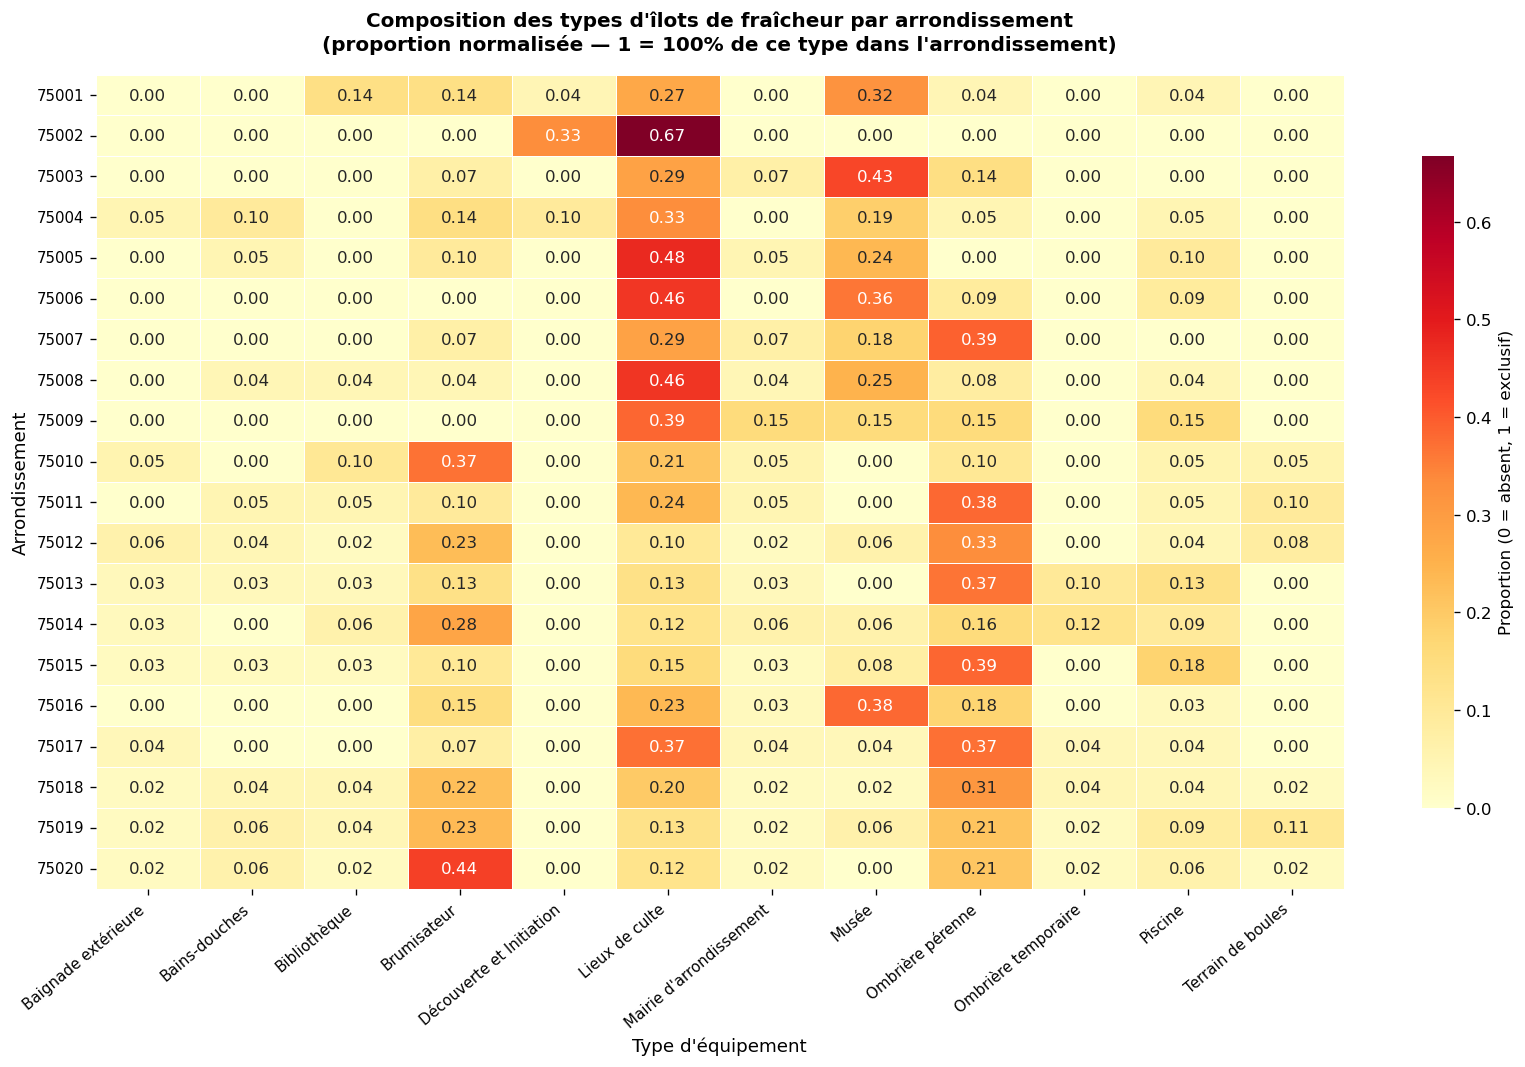

📊 Graphique sauvegardé : heatmap_type_arrondissement.png


In [22]:
# ============================================================
# CELLULE 11 — Heatmap crosstab : type d'équipement × arrondissement
# Révèle les patterns de spécialisation géographique
# ============================================================

cross = pd.crosstab(df['arrondissement'], df['type'], normalize='index').round(3)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    cross,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Proportion (0 = absent, 1 = exclusif)', 'shrink': 0.8},
    ax=ax
)

ax.set_title("Composition des types d'îlots de fraîcheur par arrondissement\n(proportion normalisée — 1 = 100% de ce type dans l'arrondissement)",
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Type d'équipement", fontsize=11)
ax.set_ylabel('Arrondissement', fontsize=11)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_type_arrondissement.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Graphique sauvegardé : heatmap_type_arrondissement.png')

## 📌 Interprétation — Heatmap type × arrondissement

Cette heatmap révèle **la spécialisation géographique** des îlots de fraîcheur :
- Les cases **foncées** indiquent une forte présence d'un type d'équipement dans un arrondissement
- Les cases **claires** indiquent une absence

On peut ainsi identifier si certains arrondissements dépendent exclusivement d'un seul type
(ex : uniquement des fontaines, sans parcs ni piscines), ce qui constitue une vulnérabilité.

---
## 📈 CELLULE 12 — Clustering KMeans : méthode du coude

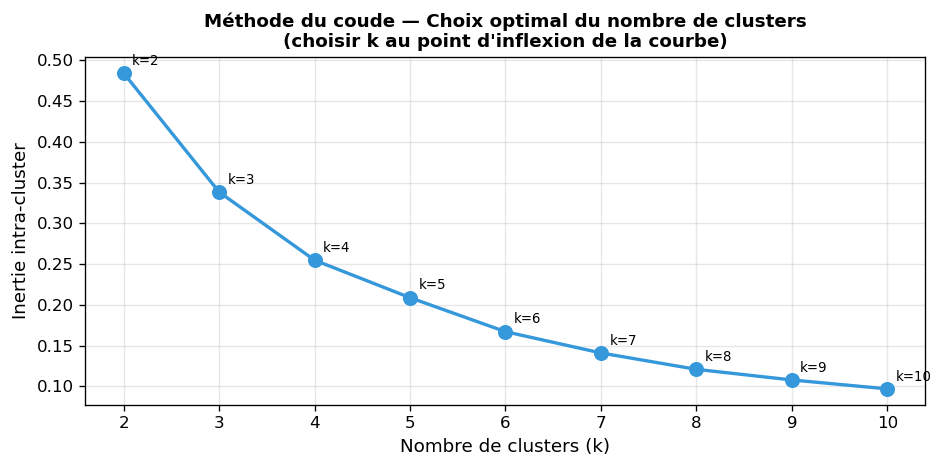

📊 Graphique sauvegardé : methode_du_coude.png
→ Examinez la courbe et choisissez k là où la descente s'aplatit.
→ Modifier K_OPTIMAL dans la cellule suivante en conséquence.


In [23]:
# ============================================================
# CELLULE 12 — Clustering KMeans avec méthode du coude
# On détermine le nombre optimal de clusters SCIENTIFIQUEMENT
# ============================================================

coords = df[['geo_point_2d.lat', 'geo_point_2d.lon']].values

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color='#3498db', linewidth=2, markersize=8)
ax.set_xlabel('Nombre de clusters (k)', fontsize=11)
ax.set_ylabel('Inertie intra-cluster', fontsize=11)
ax.set_title("Méthode du coude — Choix optimal du nombre de clusters\n(choisir k au point d'inflexion de la courbe)",
             fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)

for k, inertia in zip(K_range, inertias):
    ax.annotate(f'k={k}', (k, inertia), textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.savefig('methode_du_coude.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 Graphique sauvegardé : methode_du_coude.png')
print("→ Examinez la courbe et choisissez k là où la descente s'aplatit.")
print("→ Modifier K_OPTIMAL dans la cellule suivante en conséquence.")

---
## 🗂️ CELLULE 13 — Application du clustering avec k optimal

In [ ]:
# ============================================================
# CELLULE 13 — Application du clustering avec k optimal
# Modifier K_OPTIMAL selon la méthode du coude ci-dessus
# ============================================================

K_OPTIMAL = 5  

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(coords)

print(f'✅ Clustering appliqué avec k={K_OPTIMAL}')
print()

print('=== PROFIL DE CHAQUE CLUSTER ===')
for c in range(K_OPTIMAL):
    subset = df[df['cluster'] == c]
    print(f'\nCluster {c} ({len(subset)} équipements) :')
    print(f'  → Arrondissements : {subset["arrondissement"].value_counts().head(3).to_dict()}')
    print(f'  → Types dominants : {subset["type"].value_counts().head(3).to_dict()}')
    centroid = kmeans.cluster_centers_[c]
    print(f'  → Centroïde : lat={centroid[0]:.4f}, lon={centroid[1]:.4f}')

✅ Clustering appliqué avec k=5

=== PROFIL DE CHAQUE CLUSTER ===

Cluster 0 (133 équipements) :
  → Arrondissements : {'75013': 22, '75005': 21, '75004': 21}
  → Types dominants : {'Lieux de culte': 36, 'Musée': 27, 'Brumisateur': 18}
  → Centroïde : lat=48.8457, lon=2.3456

Cluster 1 (125 équipements) :
  → Arrondissements : {'75015': 38, '75016': 34, '75007': 21}
  → Types dominants : {'Ombrière pérenne': 39, 'Lieux de culte': 31, 'Musée': 22}
  → Centroïde : lat=48.8542, lon=2.2944

Cluster 2 (84 équipements) :
  → Arrondissements : {'75018': 31, '75017': 15, '75008': 15}
  → Types dominants : {'Lieux de culte': 28, 'Ombrière pérenne': 16, 'Musée': 10}
  → Centroïde : lat=48.8833, lon=2.3324

Cluster 3 (102 équipements) :
  → Arrondissements : {'75019': 45, '75010': 17, '75018': 14}
  → Types dominants : {'Brumisateur': 27, 'Ombrière pérenne': 22, 'Lieux de culte': 19}
  → Centroïde : lat=48.8798, lon=2.3755

Cluster 4 (103 équipements) :
  → Arrondissements : {'75012': 45, '75020':

---
## 🗺️ CELLULE 14 — Carte interactive Folium : points par type

In [26]:
# ============================================================
# CELLULE 14 — Carte interactive Folium : points colorés par type
# Avec pop-ups informatifs et légende
# ============================================================

types_uniques = df['type'].unique()
palette = ['blue', 'green', 'red', 'purple', 'orange', 'darkblue',
           'darkgreen', 'darkred', 'cadetblue', 'pink']
type_colors = {t: palette[i % len(palette)] for i, t in enumerate(types_uniques)}

map_paris = folium.Map(location=[48.8566, 2.3522], zoom_start=12, tiles='CartoDB positron')

for _, row in df.iterrows():
    color = type_colors.get(row['type'], 'gray')
    popup_html = f"""
    <div style='font-family:Arial; font-size:13px; min-width:180px'>
    <b>{row['nom']}</b><br>
    <span style='color:#555'>Type : </span>{row['type']}<br>
    <span style='color:#555'>Arrondissement : </span>{row['arrondissement']}
    </div>"""
    folium.CircleMarker(
        location=[row['geo_point_2d.lat'], row['geo_point_2d.lon']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(map_paris)

legend_items = ''.join([f"<span style='color:{v}'>■</span> {k}<br>" for k, v in type_colors.items()])
legend_html = f"""
<div style='position:fixed; bottom:20px; left:20px; z-index:1000;
background:white; padding:14px 18px; border-radius:8px;
border:1px solid #ccc; font-size:12px; font-family:Arial;
max-height:260px; overflow-y:auto; box-shadow:0 2px 8px rgba(0,0,0,0.15);'>
<b style='font-size:13px'>Types d'équipements</b><br><br>
{legend_items}
</div>"""
map_paris.get_root().html.add_child(folium.Element(legend_html))

map_paris.save('carte_ilots_types.html')
print('🗺️  Carte sauvegardée : carte_ilots_types.html')
map_paris

🗺️  Carte sauvegardée : carte_ilots_types.html


---
## 🗺️ CELLULE 15 — Carte clusters géographiques

In [27]:
# ============================================================
# CELLULE 15 — Carte clusters avec légende et pop-ups
# Chaque cluster est coloré différemment
# ============================================================

cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12',
                  '#1abc9c', '#e67e22', '#34495e']

map_cluster = folium.Map(location=[48.8566, 2.3522], zoom_start=12, tiles='CartoDB positron')

for _, row in df.iterrows():
    c_idx = int(row['cluster'])
    color = cluster_colors[c_idx % len(cluster_colors)]
    popup_html = f"""
    <div style='font-family:Arial; font-size:13px'>
    <b>{row['nom']}</b><br>
    Type : {row['type']}<br>
    Cluster : <b>#{c_idx}</b>
    </div>"""
    folium.CircleMarker(
        location=[row['geo_point_2d.lat'], row['geo_point_2d.lon']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=220)
    ).add_to(map_cluster)

legend_cl = ''.join([f"<span style='color:{cluster_colors[i]}'>■</span> Cluster {i}<br>"
                     for i in range(K_OPTIMAL)])
legend_html2 = f"""
<div style='position:fixed; bottom:20px; left:20px; z-index:1000;
background:white; padding:14px 18px; border-radius:8px;
border:1px solid #ccc; font-size:12px; font-family:Arial;'>
<b>Clusters géographiques</b><br><br>{legend_cl}
</div>"""
map_cluster.get_root().html.add_child(folium.Element(legend_html2))

map_cluster.save('carte_clusters.html')
print('🗺️  Carte sauvegardée : carte_clusters.html')
map_cluster

🗺️  Carte sauvegardée : carte_clusters.html


---
## 🔥 CELLULE 16 — Heatmap de densité (carte thermique)

In [28]:
# ============================================================
# CELLULE 16 — Heatmap de densité (carte thermique)
# Montre les zones de concentration des îlots de fraîcheur
# ============================================================

heat_data = df[['geo_point_2d.lat', 'geo_point_2d.lon']].values.tolist()

map_heat = folium.Map(location=[48.8566, 2.3522], zoom_start=12, tiles='CartoDB dark_matter')

HeatMap(
    heat_data,
    radius=18,
    blur=12,
    min_opacity=0.4,
    gradient={0.2: 'blue', 0.5: 'lime', 0.8: 'yellow', 1.0: 'red'}
).add_to(map_heat)

map_heat.save('carte_heatmap_densite.html')
print('🗺️  Carte sauvegardée : carte_heatmap_densite.html')
print("→ Rouge/Jaune = forte concentration d'îlots")
print("→ Bleu/Vert   = faible concentration")
print("→ Zones noires = absence totale d'îlots (zones à renforcer en priorité)")
map_heat

🗺️  Carte sauvegardée : carte_heatmap_densite.html
→ Rouge/Jaune = forte concentration d'îlots
→ Bleu/Vert   = faible concentration
→ Zones noires = absence totale d'îlots (zones à renforcer en priorité)


---
## ⚖️ CELLULE 17 — Indice d'inégalité (Coefficient de Gini)

In [29]:
# ============================================================
# CELLULE 17 — Calcul de l'indice d'inégalité (coefficient de Gini)
# Un seul chiffre résumant l'équité de distribution
# 0 = parfaite égalité | 1 = inégalité totale
# ============================================================

def gini(array):
    """Calcule le coefficient de Gini d'un tableau de valeurs."""
    array = np.sort(np.array(array, dtype=float))
    n = len(array)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * array) - (n + 1) * np.sum(array)) / (n * np.sum(array))

gini_brut      = gini(df_merge['nb_ilots'])
gini_normalise = gini(df_merge['ratio_pour_10000'])

print('=' * 50)
print("INDICE DE GINI — Inégalité de distribution")
print('=' * 50)
print(f"Gini brut (nb d'îlots absolu)       : {gini_brut:.3f}")
print(f"Gini normalisé (ratio/10 000 hab.)  : {gini_normalise:.3f}")
print()
print('Référence :')
print('  0.00-0.20 → Distribution très égalitaire')
print('  0.20-0.40 → Inégalité modérée')
print('  0.40-0.60 → Inégalité significative')
print('  0.60+     → Forte inégalité')
print()

if gini_normalise < 0.20:
    print('→ La distribution est RELATIVEMENT ÉQUITABLE.')
elif gini_normalise < 0.40:
    print('→ La distribution présente une INÉGALITÉ MODÉRÉE.')
elif gini_normalise < 0.60:
    print('→ La distribution présente une INÉGALITÉ SIGNIFICATIVE.')
else:
    print('→ La distribution présente une FORTE INÉGALITÉ.')

INDICE DE GINI — Inégalité de distribution
Gini brut (nb d'îlots absolu)       : 0.263
Gini normalisé (ratio/10 000 hab.)  : 0.362

Référence :
  0.00-0.20 → Distribution très égalitaire
  0.20-0.40 → Inégalité modérée
  0.40-0.60 → Inégalité significative
  0.60+     → Forte inégalité

→ La distribution présente une INÉGALITÉ MODÉRÉE.


---
## 🏆 CELLULE 18 — Synthèse chiffrée : top/flop arrondissements

In [30]:
# ============================================================
# CELLULE 18 — Synthèse chiffrée : top/flop arrondissements
# ============================================================

print('=' * 60)
print("SYNTHÈSE — Réponse à l'hypothèse de départ")
print('=' * 60)

moyenne = df_merge['ratio_pour_10000'].mean()
mediane = df_merge['ratio_pour_10000'].median()

print('\nIndicateurs globaux :')
print(f'  Ratio moyen Paris   : {moyenne:.2f} îlots / 10 000 hab.')
print(f'  Ratio médian Paris  : {mediane:.2f} îlots / 10 000 hab.')
print(f'  Coefficient de Gini : {gini_normalise:.3f}')

print('\n🟢 TOP 3 — Arrondissements les MIEUX dotés (ratio) :')
top3 = df_merge.nlargest(3, 'ratio_pour_10000')[['arrondissement', 'nb_ilots', 'population', 'ratio_pour_10000']]
for _, r in top3.iterrows():
    print(f"  {r['arrondissement']:40s} → {r['ratio_pour_10000']:.2f} îlots/10 000 hab. ({r['nb_ilots']} équipements)")

print('\n🔴 FLOP 3 — Arrondissements les MOINS dotés (ratio) :')
flop3 = df_merge.nsmallest(3, 'ratio_pour_10000')[['arrondissement', 'nb_ilots', 'population', 'ratio_pour_10000']]
for _, r in flop3.iterrows():
    print(f"  {r['arrondissement']:40s} → {r['ratio_pour_10000']:.2f} îlots/10 000 hab. ({r['nb_ilots']} équipements)")

print(f'\n📊 Écart max / min : x{(df_merge["ratio_pour_10000"].max() / df_merge["ratio_pour_10000"].min()):.1f}')
print()
sous_moyenne = df_merge[df_merge['ratio_pour_10000'] < moyenne]
print(f'Arrondissements sous la moyenne : {len(sous_moyenne)} sur {len(df_merge)}')

SYNTHÈSE — Réponse à l'hypothèse de départ

Indicateurs globaux :
  Ratio moyen Paris   : 3.53 îlots / 10 000 hab.
  Ratio médian Paris  : 2.40 îlots / 10 000 hab.
  Coefficient de Gini : 0.362

🟢 TOP 3 — Arrondissements les MIEUX dotés (ratio) :
  75001                                    → 13.53 îlots/10 000 hab. (22 équipements)
  75004                                    → 7.56 îlots/10 000 hab. (21 équipements)
  75008                                    → 6.52 îlots/10 000 hab. (24 équipements)

🔴 FLOP 3 — Arrondissements les MOINS dotés (ratio) :
  75002                                    → 1.42 îlots/10 000 hab. (3 équipements)
  75011                                    → 1.43 îlots/10 000 hab. (21 équipements)
  75017                                    → 1.61 îlots/10 000 hab. (27 équipements)

📊 Écart max / min : x9.5

Arrondissements sous la moyenne : 14 sur 20


---
#  Conclusion — Réponse à l'hypothèse centrale

## ❓ Question : *"Paris garantit-elle une équité d'accès aux îlots de fraîcheur selon les arrondissements ?"*

## 🔬 Résultats des tests statistiques

**Test de Spearman** : mesure si les arrondissements les plus peuplés ont proportionnellement plus d'îlots.
> → *Résultat : à compléter après exécution (ρ et p-value)*

**Test du Chi²** : compare la distribution réelle à une distribution parfaitement équitable.
> → *Résultat : à compléter après exécution*

**Coefficient de Gini** : résume l'inégalité en un seul chiffre.
> → *Résultat : à compléter après exécution*

## 📌 Réponse à H0/H1

> *À compléter avec les chiffres réels obtenus — exemple :*
>
> "Le test du Chi² (p = 0.001 < 0.05) nous permet de **rejeter H0** : la distribution des îlots de fraîcheur
> à Paris n'est **pas proportionnelle à la population**. L'arrondissement X dispose de Y îlots pour 10 000 habitants,
> soit Z fois la moyenne parisienne (M), tandis que l'arrondissement A n'atteint que B.
> Le coefficient de Gini de C confirme une inégalité [modérée / significative]."

##  Recommandations pour la Ville de Paris

1. **Priorité haute** : Renforcer l'équipement des arrondissements sous la moyenne dont la population est la plus élevée (flop 3)
2. **Diversification** : Certains arrondissements dépendent d'un seul type d'équipement (cf. heatmap) — diversifier l'offre
3. **Zones blanches** : Les clusters géographiques révèlent des zones sans aucun équipement — à équiper en priorité
4. **Suivi** : Mettre en place un indicateur annuel ratio/habitant par arrondissement pour mesurer la progression

## ⚠️ Limites et précautions d'interprétation

- Cette analyse repose sur les seuls équipements **référencés dans l'Open Data** — des équipements privés ou non déclarés peuvent exister
- Un équipement n'est pas équivalent à un autre : une grande piscine a une capacité d'accueil bien supérieure à une fontaine Wallace
- La proximité géographique des arrondissements signifie qu'un équipement peut servir des habitants de plusieurs arrondissements
- Les données de population (INSEE 2021) peuvent ne pas refléter les mouvements récents de population